# Food Volume from FoodSAM + ZoeDepth (Metric)

We back-project FoodSAM masks with ZoeDepth metric predictions to approximate food volumes in **metric units**. Without explicit camera intrinsics or a reference object, we auto-tune a plausible focal length by keeping the tabletop/background as flat as possible, then integrate heights above that support plane.

## What This Notebook Does

- scan every Nutrition50 dish that has both FoodSAM masks and ZoeDepth depth maps
- estimate pinhole intrinsics (focal length) from background pixels so the support plane is maximally flat
- lift each non-background mask into 3D, compute height fields, and integrate to obtain metric volumes
- capture a couple of 3D point-cloud previews so we can visually inspect the reconstruction
- persist per-mask/per-category CSV + JSON reports under `Week6/nutrition50_volume/`

In [8]:
import json
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  # needed for 3D projection


## Locate ZoeDepth + FoodSAM Outputs

Set the directories that already live in this repo. Adjust here if the dataset moves.

In [9]:
BASE_DIR = Path('.').resolve()
SAM_DIR = BASE_DIR /'../FoodSAM/nutrition50_foodSAM_outputs'
DEPTH_DIR = BASE_DIR /'../FoodSAM/zoedepth_nutrition50_outputs'
OUTPUT_DIR = BASE_DIR / 'nutrition50_volume'
PLOT_DIR = OUTPUT_DIR / 'quicklooks'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

shared_dishes = sorted(
    set(p.name for p in SAM_DIR.iterdir() if p.is_dir()) &
    set(p.name for p in DEPTH_DIR.iterdir() if p.is_dir())
)

print(f'Found {len(shared_dishes)} dishes with both segmentation and depth data.')
if not shared_dishes:
    raise RuntimeError('No overlapping dishes located; check directory paths.')


Found 50 dishes with both segmentation and depth data.


## Geometry Helpers

All the heavy lifting sits here:
1. read FoodSAM metadata, masks, and labels
2. stitch a global background mask
3. sweep focal lengths (FOV) by measuring how flat the background becomes in 3D
4. fit a support plane per mask and integrate heights to get metric volumes
5. render optional 3D previews for sanity-checks

In [10]:
FOV_SWEEP_DEGREES = np.linspace(45.0, 75.0, 13)  # plausible smartphone range
MIN_SUPPORT_PIXELS = 120
RING_KERNEL_PX = 9
SAMPLE_PLOTS = 2


def load_semantic_mapping(label_path: Path) -> Dict[int, str]:
    mapping: Dict[int, str] = {}
    with open(label_path, 'r') as f:
        header = f.readline()
        for line in f:
            parts = line.strip().split(',')
            if len(parts) < 3:
                continue
            mapping[int(parts[0])] = parts[2].strip()
    return mapping


def load_mask(mask_path: Path) -> np.ndarray:
    mask_img = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask_img is None:
        raise FileNotFoundError(mask_path)
    return mask_img > 0


def build_background_mask(mask_ids: Iterable[int], mask_dir: Path, mapping: Dict[int, str], shape: Tuple[int, int]) -> np.ndarray:
    background = np.zeros(shape, dtype=bool)
    for mask_id in mask_ids:
        if mapping.get(mask_id, '').lower() != 'background':
            continue
        background |= load_mask(mask_dir / f'{mask_id}.png')
    return background


def compute_intrinsics(width: int, height: int, fov_deg: float) -> Tuple[float, float, float, float]:
    cx = (width - 1) / 2.0
    cy = (height - 1) / 2.0
    fx = 0.5 * width / np.tan(np.deg2rad(fov_deg) / 2.0)
    fy = fx  # assume square pixels
    return fx, fy, cx, cy


def depth_to_points(depth: np.ndarray, fx: float, fy: float, cx: float, cy: float, mask: np.ndarray) -> np.ndarray:
    if mask.sum() == 0:
        return np.empty((0, 3), dtype=np.float32)
    v_idx, u_idx = np.nonzero(mask)
    z = depth[v_idx, u_idx]
    valid = np.isfinite(z) & (z > 0)
    if not np.any(valid):
        return np.empty((0, 3), dtype=np.float32)
    u = u_idx[valid].astype(np.float32)
    v = v_idx[valid].astype(np.float32)
    z = z[valid].astype(np.float32)
    x = (u - cx) * z / fx
    y = (v - cy) * z / fy
    pts = np.stack((x, y, z), axis=1)
    return pts


def fit_plane(points: np.ndarray) -> Tuple[np.ndarray, float]:
    if points.shape[0] < 3:
        raise RuntimeError('Need at least 3 points to fit a plane.')
    centroid = points.mean(axis=0)
    demeaned = points - centroid
    _, _, vh = np.linalg.svd(demeaned, full_matrices=False)
    normal = vh[-1]
    if normal[2] > 0:  # orient towards camera (negative Z)
        normal = -normal
    normal = normal / np.linalg.norm(normal)
    d = -np.dot(normal, centroid)
    return normal, d


def plane_residual(points: np.ndarray, normal: np.ndarray, d: float) -> float:
    distances = np.dot(points, normal) + d
    return float(np.sqrt(np.mean(distances**2)))


def extract_support_ring(mask: np.ndarray, background_mask: np.ndarray, kernel_px: int) -> np.ndarray:
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_px, kernel_px))
    dilated = cv2.dilate(mask.astype(np.uint8), kernel, iterations=1).astype(bool)
    ring = np.logical_and(dilated, ~mask)
    return np.logical_and(ring, background_mask)


def make_support_mask(mask: np.ndarray, background_mask: np.ndarray) -> np.ndarray:
    for radius in [RING_KERNEL_PX, RING_KERNEL_PX * 2, RING_KERNEL_PX * 3]:
        ring = extract_support_ring(mask, background_mask, radius)
        if ring.sum() >= MIN_SUPPORT_PIXELS:
            return ring
    fallback = np.logical_and(background_mask, ~mask)
    return fallback


def auto_calibrate_fov(
    depth: np.ndarray,
    masks: Dict[int, np.ndarray],
    background_mask: np.ndarray,
    width: int,
    height: int,
) -> Tuple[float, float, float, float, float]:
    best_fov = None
    best_residual = np.inf
    for fov in FOV_SWEEP_DEGREES:
        fx, fy, cx, cy = compute_intrinsics(width, height, fov)
        residuals = []
        for mask in masks.values():
            support_mask = make_support_mask(mask, background_mask)
            if support_mask.sum() < MIN_SUPPORT_PIXELS:
                continue
            pts = depth_to_points(depth, fx, fy, cx, cy, support_mask)
            if pts.shape[0] < MIN_SUPPORT_PIXELS:
                continue
            try:
                normal, d = fit_plane(pts)
            except RuntimeError:
                continue
            residuals.append(plane_residual(pts, normal, d))
        if not residuals:
            continue
        mean_res = float(np.mean(residuals))
        if mean_res < best_residual:
            best_residual = mean_res
            best_fov = fov
    if best_fov is None:
        raise RuntimeError('Auto-calibration failed: not enough support pixels.')
    fx, fy, cx, cy = compute_intrinsics(width, height, best_fov)
    return fx, fy, cx, cy, best_fov


def compute_volume_stats(
    depth: np.ndarray,
    mask: np.ndarray,
    background_mask: np.ndarray,
    fx: float,
    fy: float,
    cx: float,
    cy: float,
) -> Tuple[Dict[str, float], np.ndarray, float, np.ndarray, np.ndarray]:
    support_mask = make_support_mask(mask, background_mask)
    support_pts = depth_to_points(depth, fx, fy, cx, cy, support_mask)
    if support_pts.shape[0] < max(MIN_SUPPORT_PIXELS // 2, 30):
        raise RuntimeError('Support region too small for reliable plane fit.')
    normal, d = fit_plane(support_pts)
    support_residual = plane_residual(support_pts, normal, d)

    mask_pts = depth_to_points(depth, fx, fy, cx, cy, mask)
    if mask_pts.shape[0] == 0:
        raise RuntimeError('Mask contains no valid depth samples.')
    heights = np.dot(mask_pts, normal) + d
    positive = heights > 0
    if not np.any(positive):
        raise RuntimeError('Mask appears to be below the support plane.')

    mask_depth = mask_pts[:, 2]
    pixel_areas = (mask_depth**2) / (fx * fy)
    volume_m3 = float(np.sum(heights[positive] * pixel_areas[positive]))

    stats = {
        'volume_m3': volume_m3,
        'volume_ml': volume_m3 * 1e6,
        'mean_height_cm': float(np.mean(heights[positive])) * 100,
        'max_height_cm': float(np.max(heights[positive])) * 100,
        'support_rmse_mm': support_residual * 1000,
        'support_pixels': int(support_pts.shape[0]),
    }
    return stats, normal, d, mask_pts, heights


def save_point_cloud_plot(points: np.ndarray, heights: np.ndarray, output_path: Path, title: str) -> None:
    if points.shape[0] == 0:
        return
    sample_count = min(points.shape[0], 8000)
    if sample_count < points.shape[0]:
        idx = np.random.choice(points.shape[0], size=sample_count, replace=False)
        pts = points[idx]
        hts = heights[idx]
    else:
        pts = points
        hts = heights

    fig = plt.figure(figsize=(4.5, 4.5))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=hts, cmap='viridis', s=4)
    ax.set_title(title)
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    fig.colorbar(sc, ax=ax, shrink=0.6, label='Height above plane (m)')
    ax.view_init(elev=35, azim=140)
    plt.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.close(fig)


## Run Volume Sweep

Loop over all dishes: auto-calibrate FOV, integrate per-mask volumes, save reports, and collect sample plots.

In [11]:
summary_rows: List[Dict[str, float]] = []
sample_plots: List[Path] = []
scale_note = (
    'Volumes rely on ZoeDepth metric predictions. Intrinsics are auto-calibrated via plane flatness; '
    'absolute numbers may drift if the imaging setup changes.'
)

for dish_id in shared_dishes:
    depth_path = DEPTH_DIR / dish_id / 'enhance_vis_zoedepth.npy'
    depth = np.load(depth_path).astype(np.float32)
    height, width = depth.shape

    sam_dir = SAM_DIR / dish_id
    label_path = sam_dir / 'sam_mask_label' / 'semantic_masks_category.txt'
    mapping = load_semantic_mapping(label_path)

    mask_dir = sam_dir / 'sam_mask'
    available_mask_ids = sorted(int(p.stem) for p in mask_dir.glob('*.png') if p.is_file())
    masks = {
        mask_id: load_mask(mask_dir / f'{mask_id}.png')
        for mask_id in available_mask_ids
        if mapping.get(mask_id, '').lower() != 'background'
    }

    if not masks:
        print(f"Dish {dish_id}: no foreground masks detected.")
        continue

    background_mask = build_background_mask(available_mask_ids, mask_dir, mapping, depth.shape)

    try:
        fx, fy, cx, cy, best_fov = auto_calibrate_fov(depth, masks, background_mask, width, height)
    except RuntimeError as exc:
        print(f"Dish {dish_id}: calibration failed ({exc}).")
        continue

    per_mask_records = []
    per_category: Dict[str, Dict[str, float]] = {}

    for mask_id, mask in masks.items():
        category = mapping.get(mask_id, 'unknown')
        try:
            stats, normal, d, mask_pts, heights = compute_volume_stats(
                depth,
                mask,
                background_mask,
                fx,
                fy,
                cx,
                cy,
            )
        except RuntimeError as exc:
            print(f"  [mask {mask_id}] skipped: {exc}")
            continue

        record = {
            'dish_id': dish_id,
            'mask_id': mask_id,
            'category': category,
            'volume_m3': stats['volume_m3'],
            'volume_ml': stats['volume_ml'],
            'mean_height_cm': stats['mean_height_cm'],
            'max_height_cm': stats['max_height_cm'],
            'support_rmse_mm': stats['support_rmse_mm'],
            'support_pixels': stats['support_pixels'],
            'selected_fov_deg': best_fov,
            'fx': fx,
            'fy': fy,
        }
        per_mask_records.append(record)

        cat_entry = per_category.setdefault(
            category,
            {
                'volume_m3': 0.0,
                'volume_ml': 0.0,
                'heights_cm': [],
                'max_heights_cm': [],
            },
        )
        cat_entry['volume_m3'] += stats['volume_m3']
        cat_entry['volume_ml'] += stats['volume_ml']
        cat_entry['heights_cm'].append(stats['mean_height_cm'])
        cat_entry['max_heights_cm'].append(stats['max_height_cm'])

        if len(sample_plots) < SAMPLE_PLOTS:
            plot_path = PLOT_DIR / f'{dish_id}_mask_{mask_id}_pointcloud.png'
            save_point_cloud_plot(
                mask_pts,
                heights,
                plot_path,
                title=f'{dish_id} | {category} (mask {mask_id})',
            )
            sample_plots.append(plot_path)

    if not per_mask_records:
        print(f"Dish {dish_id}: no valid mask volumes.")
        continue

    dish_out = OUTPUT_DIR / dish_id
    dish_out.mkdir(parents=True, exist_ok=True)

    per_mask_df = pd.DataFrame(per_mask_records)
    per_mask_df.to_csv(dish_out / 'volumes_per_mask.csv', index=False)

    per_category_rows = []
    for cat_name, values in per_category.items():
        per_category_rows.append(
            {
                'dish_id': dish_id,
                'category': cat_name,
                'volume_m3': values['volume_m3'],
                'volume_ml': values['volume_ml'],
                'mean_height_cm': float(np.mean(values['heights_cm']))
                if values['heights_cm']
                else 0.0,
                'max_height_cm': float(np.max(values['max_heights_cm']))
                if values['max_heights_cm']
                else 0.0,
                'selected_fov_deg': best_fov,
            }
        )

    per_cat_df = pd.DataFrame(per_category_rows)
    per_cat_df.to_csv(dish_out / 'volumes_per_category.csv', index=False)

    dish_total_volume_m3 = float(sum(row['volume_m3'] for row in per_category_rows))
    dish_total_volume_ml = float(sum(row['volume_ml'] for row in per_category_rows))
    food_breakdown = ', '.join(
        f"{row['category']}: {row['volume_ml']:.1f} mL" for row in per_category_rows
    )

    payload = {
        'dish_id': dish_id,
        'scale_note': scale_note,
        'camera': {
            'fx': fx,
            'fy': fy,
            'cx': cx,
            'cy': cy,
            'selected_fov_deg': best_fov,
        },
        'totals': {
            'volume_m3': dish_total_volume_m3,
            'volume_ml': dish_total_volume_ml,
            'food_breakdown': food_breakdown,
        },
        'per_mask': per_mask_records,
        'per_category': per_category_rows,
    }
    with open(dish_out / 'volume_summary.json', 'w') as f:
        json.dump(payload, f, indent=2)

    summary_rows.extend(per_category_rows)

summary_df = pd.DataFrame(summary_rows)
if not summary_df.empty:
    summary_df.to_csv(OUTPUT_DIR / 'nutrition50_volume_summary.csv', index=False)
    display(summary_df.sort_values(['dish_id', 'volume_ml'], ascending=[True, False]).head(10))

    def _format_breakdown(df: pd.DataFrame) -> str:
        return ', '.join(f"{row.category}: {row.volume_ml:.1f} mL" for row in df.itertuples())

    dish_totals = (
        summary_df.groupby('dish_id')
        .agg(
            total_volume_m3=('volume_m3', 'sum'),
            total_volume_ml=('volume_ml', 'sum'),
        )
        .reset_index()
    )
    dish_totals['food_breakdown'] = summary_df.groupby('dish_id').apply(_format_breakdown).reset_index(drop=True)
    dish_totals.to_csv(OUTPUT_DIR / 'nutrition50_volume_dish_totals.csv', index=False)
    display(dish_totals.sort_values('total_volume_ml', ascending=False).head(10))
else:
    print('No volume records were generated.')

print('Finished processing all dishes.')
print(f'Sample plots stored at: {PLOT_DIR}')


  [mask 46] skipped: Mask appears to be below the support plane.
  [mask 48] skipped: Mask appears to be below the support plane.
  [mask 16] skipped: Mask appears to be below the support plane.
  [mask 56] skipped: Mask appears to be below the support plane.
  [mask 66] skipped: Mask appears to be below the support plane.
  [mask 67] skipped: Mask appears to be below the support plane.
  [mask 38] skipped: Mask appears to be below the support plane.
  [mask 44] skipped: Mask appears to be below the support plane.
  [mask 53] skipped: Mask appears to be below the support plane.
  [mask 9] skipped: Mask appears to be below the support plane.
  [mask 41] skipped: Mask appears to be below the support plane.
  [mask 46] skipped: Mask appears to be below the support plane.
  [mask 16] skipped: Mask appears to be below the support plane.
  [mask 18] skipped: Mask appears to be below the support plane.
  [mask 38] skipped: Mask appears to be below the support plane.
  [mask 19] skipped: Mask 

,dish_id,category,volume_m3,volume_ml,mean_height_cm,max_height_cm,selected_fov_deg
0,dish_1556572657,olives,0.000273,272.512491,1.236119,5.273700,45.0
1,dish_1556573514,cilantro mint,0.002881,2880.723616,6.135223,18.076158,45.0
2,dish_1556575014,cherry,0.000571,570.565475,1.205383,4.836380,45.0
3,dish_1556575083,cabbage,0.000785,785.031774,2.065502,6.806004,45.0
4,dish_1556575124,spring onion,0.000183,183.212784,2.180903,4.735577,45.0
5,dish_1556575124,celery stick,0.000110,110.212936,0.906537,4.761398,45.0
7,dish_1556575273,olives,0.000768,768.297623,1.709627,7.681477,45.0
8,dish_1556575273,pepper,0.000676,675.640541,2.357270,8.269203,45.0
6,dish_1556575273,cabbage,0.000639,639.067576,2.348803,6.886494,45.0
9,dish_1556575273,red beans,0.000105,105.385643,4.609720,6.880498,45.0


/tmp/ipykernel_5073/2896703757.py:172: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dish_totals['food_breakdown'] = summary_df.groupby('dish_id').apply(_format_breakdown).reset_index(drop=True)


,dish_id,total_volume_m3,total_volume_ml,food_breakdown
22,dish_1557862738,0.011831,11830.718078,"steak: 8543.6 mL, pork: 3287.1 mL"
28,dish_1557863170,0.011072,11071.862889,"avocado: 9955.4 mL, olives: 736.2 mL, cilantro..."
34,dish_1557937157,0.007772,7772.385245,"egg: 2989.1 mL, carrot: 134.0 mL, broccoli: 29..."
23,dish_1557862783,0.007479,7478.930932,"pork: 1896.2 mL, cauliflower: 5492.5 mL, potat..."
24,dish_1557862829,0.007404,7403.722672,cilantro mint: 7403.7 mL
30,dish_1557936599,0.003613,3613.400025,broccoli: 3613.4 mL
43,dish_1558026714,0.003406,3405.917994,"fried meat: 2775.1 mL, pork: 630.8 mL"
26,dish_1557863056,0.003033,3032.932346,avocado: 3032.9 mL
18,dish_1557861795,0.002979,2979.237876,lettuce: 2979.2 mL
48,dish_1558027243,0.002939,2939.320585,"bread: 270.3 mL, carrot: 740.6 mL, other ingre..."


Finished processing all dishes.
Sample plots stored at: /home/chahar/food_new/Week6/nutrition50_volume/quicklooks


## Quick 3D Previews

Inspect a couple of saved point-cloud renders (colour encodes height above the inferred support plane).

dish_1556572657_mask_3_pointcloud.png


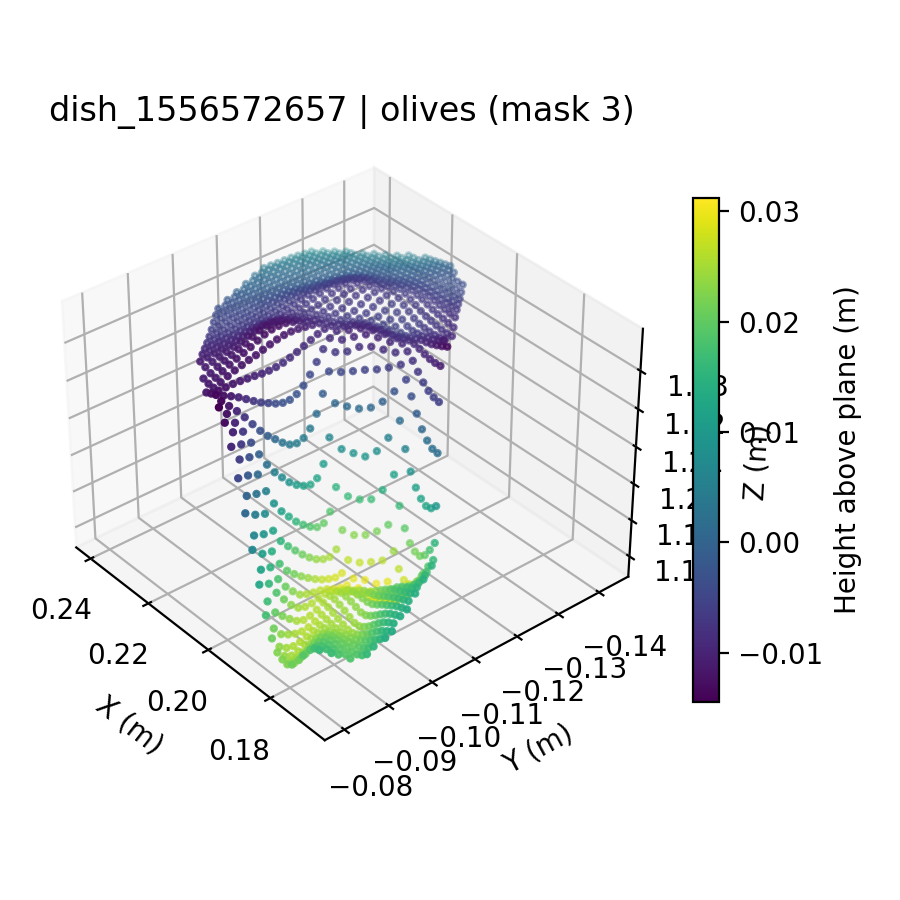

dish_1556572657_mask_4_pointcloud.png


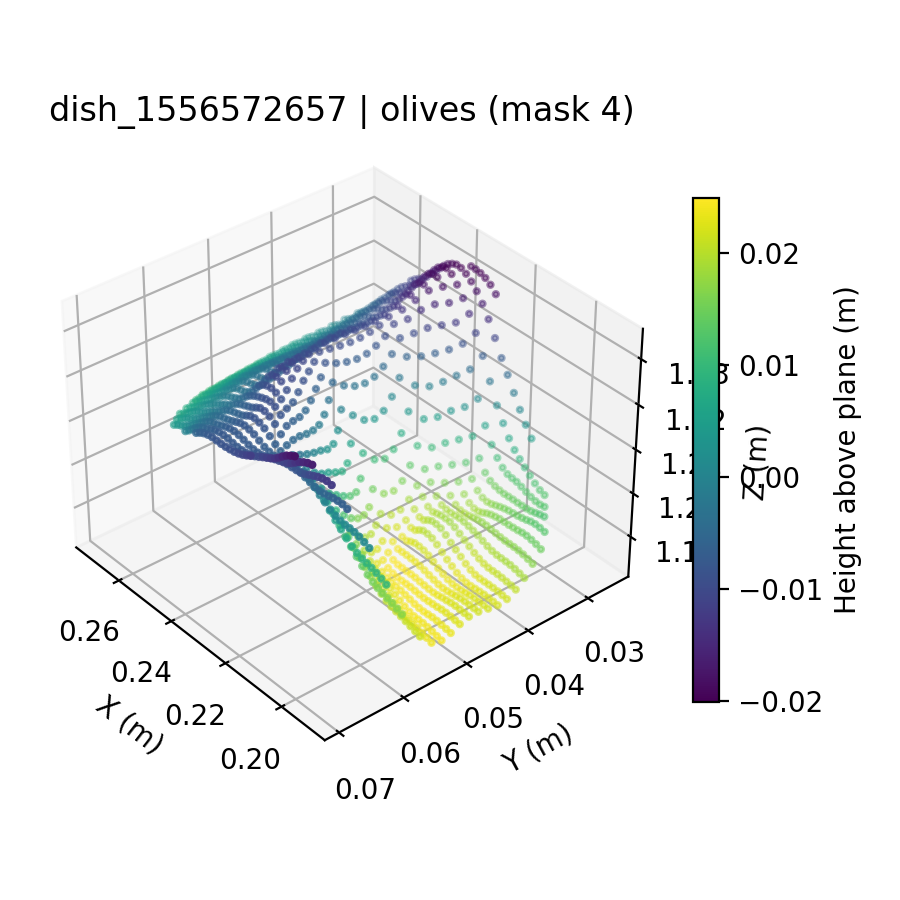

In [12]:
from IPython.display import display, Image

if sample_plots:
    for plot_path in sample_plots:
        print(plot_path.name)
        display(Image(filename=str(plot_path)))
else:
    print('No sample plots were generated (not enough valid masks).')


## Notes

- Height integration assumes ZoeDepth returns distances in metres. If the capture rig changes, re-run the FOV sweep.
- The per-pixel area uses a square-pixel approximation; for higher fidelity, replace with the exact jacobian from the actual intrinsics.
- Adding a known scale reference would let us validate (or refine) the metric conversion.